## Project 1 — Unsupervised Learning with the Abalone Dataset: EDA, k-Means, and PCA

In [8]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import itertools
from sklearn.decomposition import PCA
from IPython.display import Image, display

## Part 0 — Finding and Choosing The Dataset

**Candidates considered:** I first looked at several datasets from the UCI Machine Learning Repository, but of them many had features that were too complicated (e.g. medical terms and such) or were not usable for k-means.

**Chosen dataset:** I chose the Abalone dataset because its physical measurements are easier to interpret for clustering.

**Dataset Information:** 
- **Dataset Source:** The dataset was donated to UCI in 1995 and comes from a 1994 study of blacklip abalone from Tasmania’s North Coast and the Islands of Bass Strait.
- **Data Collectors:** The data was collected by Australia’s Department of Primary Industry and Fisheries, a government agency.
- **Documentation:** The dataset includes an `abalone.names` file explaining the source, variables, and changes made to the data.
- **Dataset Limitations:** The data only covers blacklip abalone from Tasmania, so the results may not apply to other abalone species or locations.
- **Reliability:** I trust the dataset because it comes from a government agency and is hosted by UCI, an established data repository.

**Why would someone want to perform k-means on this dataset?**
- **Motivation:** Clustering may reveal whether abalones naturally group by physical measurements.
- **Main question:** Do clusters based on physical measurements roughly correspond to abalone age?
- **Audience:** Marine biologists and fisheries managers may care because counting rings to estimate age is time-consuming.

  
Context: An abalone is a type of edible sea snail (Image below).

In [9]:
display(Image(url="https://www.foodrepublic.com/img/gallery/what-exactly-is-abalone-and-how-do-you-eat-it/how-to-store-abalone-1717527072.jpg"))

## Part 1 — Load, Inspect, and Clean

**More Dataset Information:**

Each row represents one abalone.

**Features in the dataset:**
  - `Sex`: M, F, or I for infant.
  - `Length`: mm, longest shell measurement.
  - `Diameter`: mm, measurement perpendicular to length.
  - `Height`: mm, height with meat in the shell.
  - `Whole weight`: grams, total abalone weight.
  - `Shucked weight`: grams, body meat weight.
  - `Viscera weight`: grams, internal-organ weight after bleeding.
  - `Shell weight`: grams, dried shell weight.
  - `Rings`: annual ring count, with `Rings` + 1.5 being the abalone's estimated age in years.

**Features used for clustering:** Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, and Shell weight.

**Features excluded:**
  - `Sex` was excluded because it is categorical.
  - `Rings` was excluded from clustering because it is the predicted variable.

In [10]:
url = 'https://raw.githubusercontent.com/prudhvinathreddymalla/Abalone-Dataset/refs/heads/master/Abalone%20Dataset.csv'
df = pd.read_csv(url)
dfnew = df.drop(columns = ['Sex'])
feature_names = ['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
ring_count = df['Rings'].unique()
X = dfnew[feature_names].to_numpy()
print("Dataset shape: " + str(X.shape))

Dataset shape: (4177, 7)


## Part 2 — Exploratory Data Analysis

#### 2.1 Column Statistics

In [11]:
print(f"{'Feature':<20} {'Mean':>8} {'Std':>8} {'Norm':>10}")
print('-' * 50)
for j, name in enumerate(feature_names):
    col = X[:, j]
    col_mean = np.mean(col)
    col_std  = np.std(col)
    col_norm = np.linalg.norm(col)
    print(f'{name:<20} {col_mean:>8.4f} {col_std:>8.4f} {col_norm:>10.4f}')

Feature                  Mean      Std       Norm
--------------------------------------------------
Length                 0.5240   0.1201    34.7433
Diameter               0.4079   0.0992    27.1301
Height                 0.1395   0.0418     9.4133
Whole weight           0.8287   0.4903    62.2340
Shucked weight         0.3594   0.2219    27.2980
Viscera weight         0.1806   0.1096    13.6530
Shell weight           0.2388   0.1392    17.8655


- The features' norms are not on the same scale.
- `Whole weight` has the largest norm at **62.2340**, while `Height` has the smallest norm at **9.4133**.
- Without standardization, features with larger norms, such as  `Whole weight`, would have more influence over the k-means.
- So, the features should be standardized before clustering, so each feature is able to meaningfully contribute to the k-means.

#### 2.2 Scatterplots

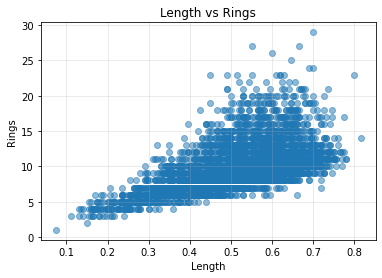

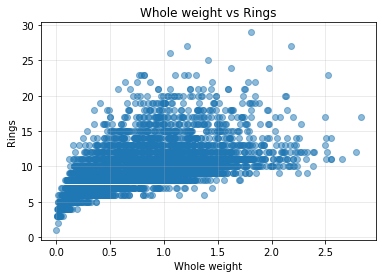

In [12]:
feature_pairs = [
    ("Length", "Rings"),
    ("Whole weight", "Rings"),
]

for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[x_feature], df[y_feature], alpha=0.5)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"{x_feature} vs {y_feature}")
    plt.grid(True, alpha=0.3)
    plt.show()

**Feature pairs chosen:** `Length` vs. `Rings` and `Whole weight` vs. `Rings`.
- I chose these features because I wanted to see whether physical growth patterns connect to abalone age.

**Length vs. Rings:** Older abalones tend to be longer, but the relationship is weak and has a lot of variation.
  
**Whole weight vs. Rings:** Heavier abalones also tend to have more rings, but, similarly to the previous scatterplot, the relationship is weak and there is a lot of variation.

**Conclusion:** Physical measurements may separate broad age groups, but the overlap suggests k-means clusters may not match age perfectly.

#### 2.2 Histograms

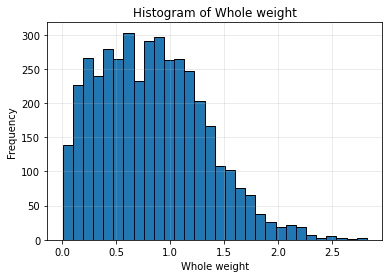

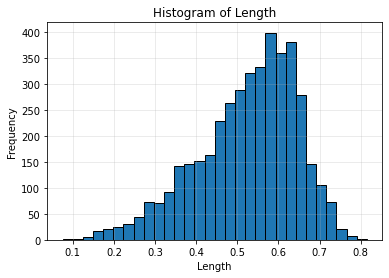

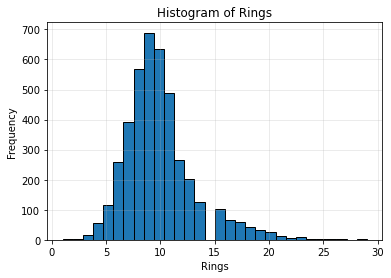

In [13]:
features = ["Whole weight", "Length", "Rings"]

for col in features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.grid(True, alpha=0.3)
    plt.show()

**Histogram Features:** The features `Length`, `Rings`, and `Whole weight` were chosen as they were the ones used for the scatterplots.

**Whole weight:** Right-skewed with most abalones are between about 0 and 1.5 grams.

**Length:** Concentrated around about 0.5 to 0.65, with fewer small abalones.

**Rings:** Right-skewed with most abalones having around 6 to 12 rings.

**Overall pattern:** Most abalones are relatively close in size and age, with few outliers.

## Part 3 — Standardization


In [14]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print('X_std shape:', X_std.shape)
print('Column norms (should all be sqrt(4177)):',
      np.round([np.linalg.norm(X_std[:, j]) for j in range(7)], 7))

X_std shape: (4177, 7)
Column norms (should all be sqrt(4177)): [64.6297145 64.6297145 64.6297145 64.6297145 64.6297145 64.6297145
 64.6297145]


- As mentioned in the 2.1 Column Statistics section, standardization is necessary because the raw feature scales are very different.
- For example, `Whole weight` has a norm of **62.2340** while `Height` has a norm of **9.4133**, and since features with larger norms would dominate the clustering, standardization is needed.
- After standardization, every feature has norm about **64.63**, which is approximately $\sqrt{4177}$.

## Part 4 — The k-Means Objective Function and Algorithm

#### 4.1 The Objective Function Explanation

$$
J^{\text{clust}} = \sum_{i=1}^{n} \left\|\mathbf{x}_i - \mathbf{c}_{g_i}\right\|^2
$$

- For this dataset, $\mathbf{x}_i$ represents the abalone's physical measurements such as length, diameter, height, and weight.
- $\mathbf{c}_{g_i}$ is the center, or centroid, of the cluster that abalone ($x_i$) is assigned to.
- $\left\|\mathbf{x}_i - \mathbf{c}_{g_i}\right\|^2$ is the distance from one abalone to the center of its cluster.
- Minimizing $J^{\text{clust}}$ means grouping abalones into cluster that contain other, similar abalones.

#### 4.2 Lloyd's Algorithm Explanation

- Choose the number of clusters, $k$.
- Pick starting centroids for the clusters.
- Assign each abalone to the nearest centroid using its standardized measurements.
- Recalculate each centroid as the average of the abalones assigned to that cluster.
- Repeat the assign-and-update steps until the cluster assignments or $J^{\text{clust}}$ stop changing.
- When we use `KMeans(n_clusters=k, n_init=10, random_state=0)`, we choose the number of clusters and initializations. Then when we use `fit_predict()` on the standardized abalone features, Scikit-learn assigns each abalone to the nearest centroid, updates the centroids, and repeats until the clusters are stop changing.
- The result is a cluster label for each abalone. With the labels showing which group each abalone belongs to based on its physical measurements.

## Part 5 — k-Means with Scikit-learn

#### 5.1 Elbow Plot

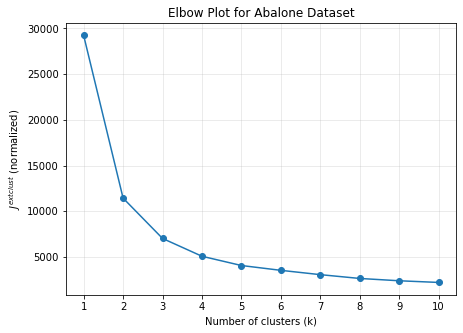

In [15]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X_std)
    inertias.append(kmeans.inertia_)

# Make elbow plot
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("$J^{\text{clust}}$ (normalized)")
plt.title("Elbow Plot for Abalone Dataset")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

- For the elbow plot, I tested $k$ values from **1 to 10** and used an `n_init=10`.
- The elbow appears around **$k=2$ to $k=3$**.
- I chose **$k=2$** because as the two k-means clusters could be interpreted as a split between smaller/younger-looking abalones and larger/older-looking abalones.
- Though, there is not a commonly agreed upon point where an abalone is considered old rather than young.

#### 5.2 Final Model

In [17]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_std)

print("Cluster label counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster percentages:")
print((df["Cluster"].value_counts(normalize=True).sort_index() * 100).round(4))

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_names
)

print("\nCluster centroids in standardized space:")
print(centroids.round(4))

Cluster label counts:
0    1939
1    2238
Name: Cluster, dtype: int64

Cluster percentages:
0    46.4209
1    53.5791
Name: Cluster, dtype: float64

Cluster centroids in standardized space:
   Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0 -0.8548   -0.8580 -0.7594       -0.8666         -0.8350         -0.8474   
1  0.7398    0.7426  0.6573        0.7501          0.7227          0.7335   

   Shell weight  
0       -0.8453  
1        0.7316  


- Cluster 0 contains **1,939 abalones**, or **46.4209%** of the dataset.
- Cluster 1 contains **2,238 abalones**, or **53.5791%** of the dataset.
- As such, the clusters are roughly balanced.
- Cluster 0 has negative standardized centroid values, meaning it represents smaller and lighter abalones.
- While Cluster 1 has the opposite, meaning it represents larger and heavier abalones.
- So, this means that the k-means mainly separated abalones by overall size and weight.

## Part 6 — PCA and Visualization

#### 6.1 PCA — Variance Explained

In [18]:
pca = PCA(n_components=2)
V = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print(f'PC1 explains {evr[0]*100:.1f}% of total variance')
print(f'PC2 explains {evr[1]*100:.1f}% of total variance')
print(f'Together:    {sum(evr)*100:.1f}%')

PC1 explains 90.8% of total variance
PC2 explains 4.0% of total variance
Together:    94.8%


- PC1 explains **90.8%** of the total variance.
- PC2 explains **4.0%** of the total variance.
- Together, PC1 and PC2 explain **94.8%** of the variance, so the 2D PCA plot should represent the data well.
- This also means that the data has low intrinsic dimensionality because most variation is explained.
- Since PC1 explains most of the variance, we can assume that most of the data trends towards one direction.

#### 6.2 Visualization

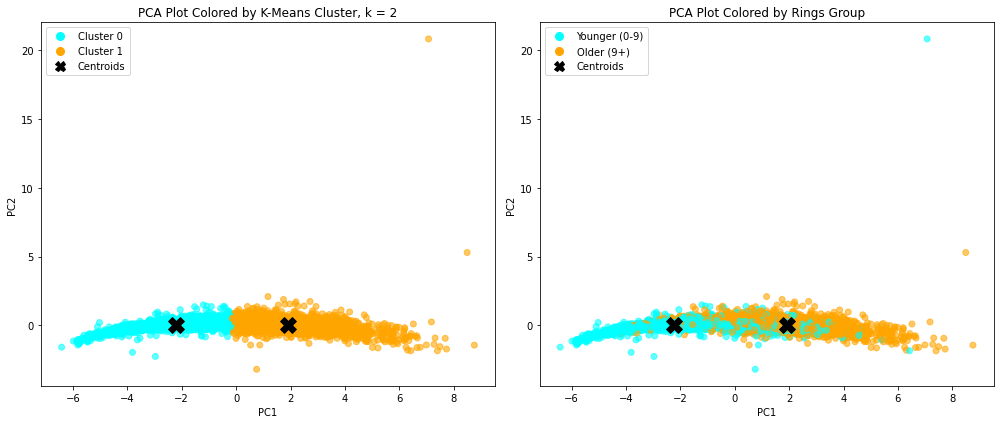

In [23]:
from matplotlib.colors import ListedColormap

# Create 2 Rings groups using actual ring-count ranges
df["Rings_group"] = np.select(
    [
        df["Rings"] <= 9,
        df["Rings"] > 9
    ],
    [
        "Younger (0-9)",
        "Older (9+)"
    ]
)

# Transform k-means centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Blue/orange color map
blue_orange_cmap = ListedColormap(["cyan", "orange"])
group_colors = ["cyan", "orange"]

# Convert k-means clusters to numeric codes for coloring
cluster_categories = pd.Categorical(df["Cluster"], ordered=True)
cluster_codes = cluster_categories.codes
cluster_labels = [f"Cluster {label}" for label in cluster_categories.categories]

# Convert Rings groups to numeric codes for coloring
rings_categories = pd.Categorical(
    df["Rings_group"],
    categories=["Younger (0-9)", "Older (9+)"],
    ordered=True
)
ring_codes = rings_categories.codes

# Create two-panel plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: k-means clusters
axes[0].scatter(
    V[:, 0],
    V[:, 1],
    c=cluster_codes,
    cmap=blue_orange_cmap,
    alpha=0.6
)

axes[0].scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Plot Colored by K-Means Cluster, k = 2")

# Legend for k-means clusters
cluster_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        label=label,
        markersize=8,
        markerfacecolor=color,
        markeredgecolor=color
    )
    for label, color in zip(cluster_labels, group_colors)
]

cluster_handles.append(
    plt.Line2D(
        [0], [0],
        marker="X",
        linestyle="",
        color="black",
        label="Centroids",
        markersize=10
    )
)

axes[0].legend(handles=cluster_handles)

# Right panel: Rings groups
axes[1].scatter(
    V[:, 0],
    V[:, 1],
    c=ring_codes,
    cmap=blue_orange_cmap,
    alpha=0.6
)

axes[1].scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("PCA Plot Colored by Rings Group")

# Legend for Rings groups
ring_labels = ["Younger (0-9)", "Older (9+)"]
ring_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        label=label,
        markersize=8,
        markerfacecolor=color,
        markeredgecolor=color
    )
    for label, color in zip(ring_labels, group_colors)
]

ring_handles.append(
    plt.Line2D(
        [0], [0],
        marker="X",
        linestyle="",
        color="black",
        label="Centroids",
        markersize=10
    )
)

axes[1].legend(handles=ring_handles)

plt.tight_layout()
plt.show()

- The k-means PCA plot separates most abalones from left to right along PC1.
- The split occurs around **PC1 = 0**, mainly separating the data by overall size and weight.
- The centroids are separated, but there is overlap near the middle showing how some abalones are between the two groups and are harder to classify correctly.
- This can also be seen on the right PCA plot with the ground-truth label (`Rings`), younger abalones are more common on the left and older abalones are more common on the right.
- Though there is still substantial overlap between younger and older groups.
- Overall, k-means broadly agrees with age groups, with younger abalones being on the left and vice versa, but it does not classify abalone age very accurately.

## Part 7 — Reflection

Before analyzing the dataset, I thought that there would be a stronger correlation between the age of an abalone and its size. Which was proven wrong with how much overlap can be seen on the PCA plot with ground-truth labels as well as the scatterplots comparing `Rings` to `Whole weight` and `Length`. 

With the amount of overlap seen on the graph, those wanting to find the relative age of an abalone without going through the time consuming task of counting its rings would only be able to somewhat accurate guess using a k-means algorithm if its measurements leave it on the far side of one of the clusters.

So, the clusters are mostly meaningful, with the smaller abalones being separated from the larger ones, but only somewhat matching the age groups. While this might be a result of only creating 2 clusters and the addition of some more clusters would be unlikely to cause a significant increase in accurate groupings given the large amount of variation in abalone size within age ranges. The 2D PCA view is trustworthy since together PC1 and PC2 explain **94.8%** of the variance, though PC1 explains most of it. 

A question I would like to investigate is if using a different type of model would work better for prediction the age of abalone. To do this I would need to learn how to make other types of models in python.